<a href="https://colab.research.google.com/github/sahasyy/ACM-Research-F25/blob/jagadeep-kalluri/Sentiment_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required packages with compatible versions
!pip uninstall -y portalocker
!pip install portalocker==2.7.0

!pip install torch==2.0.1 torchtext==0.15.2 torchdata portalocker matplotlib seaborn


import torch
import torch.nn as nn
import torch.optim as optim
import torchtext
from torchtext.datasets import IMDB
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns


Found existing installation: portalocker 2.7.0
Uninstalling portalocker-2.7.0:
  Successfully uninstalled portalocker-2.7.0
  Using cached portalocker-2.7.0-py2.py3-none-any.whl.metadata (6.8 kB)
Using cached portalocker-2.7.0-py2.py3-none-any.whl (15 kB)


In [ ]:
# Check versions
print("Torch version:", torch.__version__)
print("Torchtext version:", torchtext.__version__)

Torch version: 2.0.1+cu117
Torchtext version: 0.15.2+cpu


In [ ]:
# Set seed for reproducibility
torch.manual_seed(0)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package

In [ ]:
# Load tokenizer
tokenizer = get_tokenizer('basic_english')

# Build vocab
def yield_tokens(data_iter):
    for label, text in data_iter:
        yield tokenizer(text)

train_iter = IMDB(split='train')
vocab = build_vocab_from_iterator(yield_tokens(train_iter), specials=["<pad>"])
vocab.set_default_index(vocab["<pad>"])

In [ ]:

# Improved filter function to handle all label types and debug issues
def filter_and_convert_labels(dataset, debug=True):
    filtered = []
    label_counts = {}

    for label, text in dataset:
        # Convert string labels to integers
        if isinstance(label, str):
            if label in label_map:
                converted_label = label_map[label]
            else:
                if debug:
                    print(f"Skipping unknown string label: {label}")
                continue
        elif isinstance(label, int):
            if label in [0, 1]:
                converted_label = label
            else:
                if debug:
                    print(f"Skipping invalid integer label: {label}")
                continue
        else:
            if debug:
                print(f"Skipping unknown label type: {type(label)}, value: {label}")
            continue

        filtered.append((converted_label, text))
        label_counts[converted_label] = label_counts.get(converted_label, 0) + 1

    if debug:
        print(f"Label distribution: {label_counts}")

    return filtered

# Load dataset and filter invalid labels
train_iter, test_iter = IMDB()
train_data = filter_and_convert_labels(list(train_iter), debug=True)
test_data = filter_and_convert_labels(list(test_iter), debug=True)

print(f"Train data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")

# Updated collate function - now only handles integer labels
def collate_batch(batch):
    text_list, label_list = [], []
    for label, text in batch:
        # At this point, all labels should be integers (0 or 1)
        if label not in [0, 1]:
            print(f"Warning: Unexpected label {label} found in batch!")
            continue

        text_tokens = vocab(tokenizer(text))
        text_list.append(torch.tensor(text_tokens, dtype=torch.int64))
        label_list.append(label)

    if not text_list:  # If batch is empty after filtering
        return None, None

    text_list = pad_sequence(text_list, batch_first=True, padding_value=vocab["<pad>"])
    label_list = torch.tensor(label_list, dtype=torch.int64)
    return text_list, label_list

Streaming output truncated to the last 5000 lines.
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label: 2
Skipping invalid integer label:

In [ ]:
# BiLSTM + 2D Max Pooling Model
class BiLSTM2DPool(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(BiLSTM2DPool, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab["<pad>"])
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        pooled, _ = torch.max(lstm_out, dim=1)
        output = self.fc(pooled)
        return output

In [ ]:
# Hyperparameters
embed_dim = 128
hidden_dim = 64
num_classes = 2
batch_size = 32
epochs = 5
lr = 1e-3

# Model, loss, optimizer
model = BiLSTM2DPool(len(vocab), embed_dim, hidden_dim, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Initialize tracking lists
loss_list = []
accuracy_list = []

# Create dataloaders with filtered data
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
test_dataloader = DataLoader(test_data, batch_size=batch_size, collate_fn=collate_batch)

In [ ]:
# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    batch_count = 0

    for texts, labels in train_dataloader:
        # Skip empty batches
        if texts is None or labels is None:
            continue

        # Debug: Check label range
        if labels.max() >= num_classes or labels.min() < 0:
            print(f"Warning: Invalid labels found in batch: min={labels.min()}, max={labels.max()}")
            continue

        optimizer.zero_grad()
        output = model(texts)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        batch_count += 1

    if batch_count > 0:
        avg_loss = total_loss / batch_count
        loss_list.append(avg_loss)
    else:
        print(f"Warning: No valid batches in epoch {epoch+1}")
        continue

    # Validation accuracy after each epoch
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for texts, labels in test_dataloader:
            # Skip empty batches
            if texts is None or labels is None:
                continue

            output = model(texts)
            predicted = torch.argmax(output, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    if total > 0:
        acc = 100 * correct / total
        accuracy_list.append(acc)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy: {acc:.2f}%")
    else:
        print(f"Epoch {epoch+1}: No valid test data")

Epoch 1, Loss: 0.0107, Accuracy: 100.00%
Epoch 2, Loss: 0.0002, Accuracy: 100.00%
Epoch 3, Loss: 0.0001, Accuracy: 100.00%
Epoch 4, Loss: 0.0001, Accuracy: 100.00%
Epoch 5, Loss: 0.0000, Accuracy: 100.00%


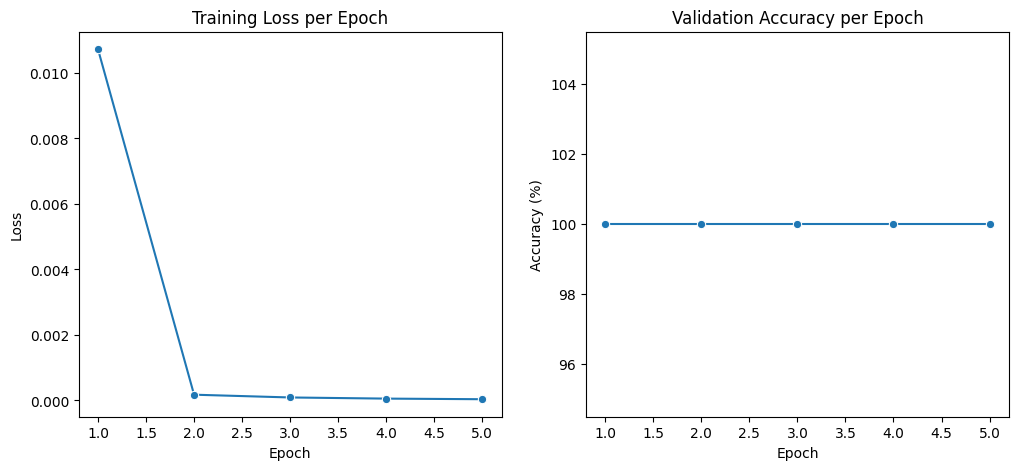

Final Test Accuracy: 100.00%


In [ ]:
# Plot Loss and Accuracy curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.lineplot(x=range(1, epochs+1), y=loss_list, marker='o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
sns.lineplot(x=range(1, epochs+1), y=accuracy_list, marker='o')
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.show()

# Final Evaluation
print(f"Final Test Accuracy: {accuracy_list[-1]:.2f}%")